# Kernels in the Machine
## How Kernel Swapping Affects Model Performance

---

Modern LLM inference stacks are increasingly modular. HuggingFace's [kernel hub](https://huggingface.co/kernels-community) lets practitioners drop in optimized, third-party CUDA or Triton kernels for individual operations — RMSNorm, attention, MLP — without touching model weights or architecture.

The appeal is obvious: faster kernels, same model. But this modularity hides a subtle trap.

> *If a kernel passes its correctness tests within atol/rtol tolerance, does that guarantee the model behaves identically?*

**No** — and this post shows exactly why.

The core issue is **error accumulation**. A Transformer is a deep composition of operations across many layers. A tiny floating-point deviation introduced by a swapped kernel in layer 1 doesn't stay tiny — it propagates forward, gets scaled, added to residual streams, normalized again, and amplified through attention and feed-forward projections. By the final layer, the model may be in a meaningfully different hidden state, generating different tokens and scoring differently on downstream benchmarks.

We'll demonstrate this using [`Qwen/Qwen3.5-0.8B`](https://huggingface.co/Qwen/Qwen3.5-0.8B) with the [`kernels-community/tinygrad-rms`](https://huggingface.co/kernels-community/tinygrad-rms) kernel, comparing behavior across both `bf16` and `fp16` precision.

## Setup

In [114]:
%%capture
!pip install torch transformers kernels datasets matplotlib seaborn numpy tqdm accelerate evalplus


In [96]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import string
import gc
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from kernels import get_kernel
import subprocess, tempfile, os, json as _json

MODEL_NAME = "Qwen/Qwen3-0.6B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device : cuda
PyTorch: 2.11.0+cu130
GPU    : NVIDIA H100 80GB HBM3
VRAM   : 85.0 GB


---

## RMSNorm: The Operation Under the Microscope

Root Mean Square Normalization ([Zhang & Sennrich, 2019](https://arxiv.org/abs/1910.07467)) is the normalization layer of choice in most modern LLMs — Qwen, LLaMA, Mistral all use it. Its formula is deceptively simple:

$$\text{RMSNorm}(\mathbf{x}) = \frac{\mathbf{x}}{\text{RMS}(\mathbf{x})} \cdot \mathbf{w}, \quad \text{where} \quad \text{RMS}(\mathbf{x}) = \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2 + \epsilon}$$

Unlike LayerNorm, RMSNorm skips the mean-subtraction step, making it cheaper to compute. But that simplicity is exactly what makes it a good optimization target — and a good case study for kernel swapping effects.

The implementation of [RMSNorm](https://github.com/huggingface/transformers/blob/0db33792ed1cc6a61d96f5d59fd0c930db2896fe/src/transformers/models/qwen3/modeling_qwen3.py#L50) in Huggingface's `transformers` library for the Qwen3 Model is shown below:

In [97]:
class Qwen3RMSNorm(nn.Module):
    def __init__(self, hidden_size, eps: float = 1e-6) -> None:
        """
        Qwen3RMSNorm is equivalent to T5LayerNorm
        """
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.variance_epsilon = eps

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        input_dtype = hidden_states.dtype
        hidden_states = hidden_states.to(torch.float32)
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        return self.weight * hidden_states.to(input_dtype)

    def extra_repr(self):
        return f"{tuple(self.weight.shape)}, eps={self.variance_epsilon}"

---

## Dropping In a Custom Kernel

HuggingFace's `kernels` package makes it straightforward to load community-contributed implementations of standard operations. The `kernels-community/tinygrad-rms` kernel is a TinyGrad-compiled RMSNorm — designed to be a fast, drop-in replacement.

Let's load it and inspect what it exposes:

In [98]:
liger_kernel_rmnsorm = get_kernel("kernels-community/liger-kernels", version=1).layers.LigerRMSNormFunction.apply

Fetching 19 files: 100%|██████████| 19/19 [00:00<00:00, 148125.98it/s]


In [99]:
def call_rms_kernel(
    kernel, hidden_states: torch.Tensor, weight: torch.Tensor, eps: float
) -> torch.Tensor:
    """Adaptively invoke the kernel using whichever calling convention it exposes."""
    for method_name in ["rms_norm", "forward"]:
        fn = getattr(kernel, method_name, None)
        if callable(fn):
            try:
                return fn(hidden_states, weight, eps)
            except TypeError:
                pass
    try:
        return kernel(hidden_states, weight, eps)
    except TypeError:
        pass
    raise RuntimeError(
        f"No working calling convention found. Available: {[a for a in dir(kernel) if not a.startswith('_')]}"
    )

---

## Part 1: Correctness Tests — And They Pass

The standard way to validate a custom kernel is to compare its outputs against a reference implementation on random inputs, within some numerical tolerance. This is the test that would appear in a kernel's CI suite.

We'll test across `float32`, `bfloat16`, and `float16`, using `atol=1e-3, rtol=1e-3` — a reasonable tolerance for mixed-precision arithmetic:

In [100]:
def test_kernel_correctness(
    kernel, dtype: torch.dtype, hidden_size: int = 1024,
    atol: float = 1e-3, rtol: float = 1e-3, seed: int = 42
):
    torch.manual_seed(seed)
    batch, seq_len = 2, 16

    hidden_states = torch.randn(batch, seq_len, hidden_size, dtype=dtype, device=DEVICE)
    weight = torch.ones(hidden_size, dtype=dtype, device=DEVICE)
    eps = 1e-6

    ref = Qwen3RMSNorm(hidden_size, eps=eps).to(dtype).to(DEVICE)
    ref.weight.data = weight.clone()

    with torch.no_grad():
        ref_out = ref(hidden_states)
        kernel_out = call_rms_kernel(kernel, hidden_states, weight, eps)

    passed = torch.allclose(ref_out.float(), kernel_out.float(), atol=atol, rtol=rtol)
    max_diff = (ref_out.float() - kernel_out.float()).abs().max().item()
    mean_diff = (ref_out.float() - kernel_out.float()).abs().mean().item()
    return passed, max_diff, mean_diff


print(f"{'dtype':<12} {'passed':<10} {'max |diff|':<15} {'mean |diff|':<15}")
print("-" * 52)
for dtype_name, dtype in [
    ("float32",   torch.float32),
    ("bfloat16",  torch.bfloat16),
    ("float16",   torch.float16),
]:
    passed, max_diff, mean_diff = test_kernel_correctness(liger_kernel_rmnsorm, dtype)
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"{dtype_name:<12} {status:<10} {max_diff:<15.2e} {mean_diff:<15.2e}")

dtype        passed     max |diff|      mean |diff|    
----------------------------------------------------
float32      ✓ PASS     4.77e-07        7.41e-09       
bfloat16     ✓ PASS     0.00e+00        0.00e+00       
float16      ✓ PASS     4.88e-04        2.24e-08       


The kernel passes. Small differences exist (floating-point arithmetic is not commutative), but they're well within tolerance. By any standard kernel validation criterion, this is a green light.

Now let's see what happens when we plug it into an actual model.

---

## Part 2: Into the Model — The Accumulation Problem

A Transformer decoder like Qwen3.5-0.8B applies RMSNorm at multiple points per layer: before self-attention, after self-attention (in some architectures), and before the MLP. With 28 layers, that's on the order of **56+ RMSNorm calls** per forward pass.

Each call introduces a small perturbation $\delta_i$. The residual stream at layer $l$ is roughly:

$$\mathbf{h}_l = \mathbf{h}_{l-1} + f_l(\text{RMSNorm}(\mathbf{h}_{l-1}))$$

So the perturbation from layer 1 gets added into $\mathbf{h}_1$, which is then passed through $f_2$, which amplifies or reshapes it, and so on. The perturbations don't cancel — they compound.

Let's load the model and build the patching infrastructure to test this.

In [101]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loading {MODEL_NAME} in bfloat16...")
model_bf16 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
model_bf16.eval()

print(f"Hidden size : {model_bf16.config.hidden_size}")
print(f"Num layers  : {model_bf16.config.num_hidden_layers}")
print(f"Parameters  : {sum(p.numel() for p in model_bf16.parameters()) / 1e6:.0f}M")

Loading Qwen/Qwen3-0.6B in bfloat16...


Loading weights: 100%|██████████| 311/311 [00:00<00:00, 1394.63it/s]


Hidden size : 1024
Num layers  : 28
Parameters  : 596M


In [102]:
def _get_rmsnorm_params(module):
    weight = module.weight
    eps = getattr(module, "variance_epsilon", getattr(module, "eps", 1e-6))
    return weight, eps


def patch_model_rmsnorm(model, kernel):
    """Replace every RMSNorm layer's forward with the kernel implementation."""
    original_forwards = {}
    for name, module in model.named_modules():
        if "RMSNorm" in type(module).__name__:
            weight, eps = _get_rmsnorm_params(module)
            original_forwards[name] = module.forward

            def _make_forward(w, e):
                def _forward(hidden_states):
                    return call_rms_kernel(kernel, hidden_states, w, e)
                return _forward

            module.forward = _make_forward(weight, eps)
    print(f"Patched {len(original_forwards)} RMSNorm modules")
    return original_forwards


def unpatch_model_rmsnorm(model, original_forwards):
    """Restore all RMSNorm layers to their original forward methods."""
    for name, module in model.named_modules():
        if name in original_forwards:
            module.forward = original_forwards[name]
    print(f"Unpatched {len(original_forwards)} RMSNorm modules")

---

## Part 3: Where Outputs First Diverge

With greedy decoding (`do_sample=False`), two identical models must produce identical tokens. Any difference in the internal computation will eventually tip the argmax at some token position — once the paths diverge, they stay diverged.

Let's run the same prompts through both the original model and the kernel-swapped model and find where they first disagree:

In [103]:
TEST_PROMPTS = [
    "The capital of France is",
    "In 1969, NASA's Apollo 11 mission successfully landed humans on",
    "The chemical symbol for gold is",
]
MAX_NEW_TOKENS = 40


def greedy_generate(model, tokenizer, prompt: str, max_new_tokens: int = 40):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_ids = out[0][input_len:].cpu().tolist()
    text = tokenizer.decode(new_ids, skip_special_tokens=True)
    return text, new_ids


divergence_data = []

for prompt in TEST_PROMPTS:
    text_orig, ids_orig = greedy_generate(model_bf16, tokenizer, prompt, MAX_NEW_TOKENS)

    orig_fwd = patch_model_rmsnorm(model_bf16, liger_kernel_rmnsorm)
    text_swap, ids_swap = greedy_generate(model_bf16, tokenizer, prompt, MAX_NEW_TOKENS)
    unpatch_model_rmsnorm(model_bf16, orig_fwd)

    divergence_point = next(
        (i for i, (a, b) in enumerate(zip(ids_orig, ids_swap)) if a != b), None
    )
    divergence_data.append({
        "prompt": prompt,
        "original": text_orig,
        "swapped": text_swap,
        "ids_orig": ids_orig,
        "ids_swap": ids_swap,
        "divergence_point": divergence_point,
    })

for d in divergence_data:
    print(f"Prompt   : {d['prompt']!r}")
    print(f"Original : {d['original']!r}")
    print(f"Swapped  : {d['swapped']!r}")
    dp = d['divergence_point']
    print(f"Diverges at token position: {dp if dp is not None else 'identical'}")
    print()

Patched 113 RMSNorm modules
Unpatched 113 RMSNorm modules
Patched 113 RMSNorm modules
Unpatched 113 RMSNorm modules
Patched 113 RMSNorm modules
Unpatched 113 RMSNorm modules
Prompt   : 'The capital of France is'
Original : ' Paris. The capital of France is also the capital of the Republic of France. The capital of France is also the capital of the European Union. The capital of France is also the capital of the United'
Swapped  : ' Paris. The capital of France is also the capital of the Republic of France. The capital of France is also the capital of the European Union. The capital of France is also the capital of the United'
Diverges at token position: identical

Prompt   : "In 1969, NASA's Apollo 11 mission successfully landed humans on"
Original : " the Moon. The Moon's surface is covered with a large number of craters, and the average number of craters per square kilometer is 1.5. What is the probability that a"
Swapped  : " the Moon. The Moon's surface is covered with a large numb

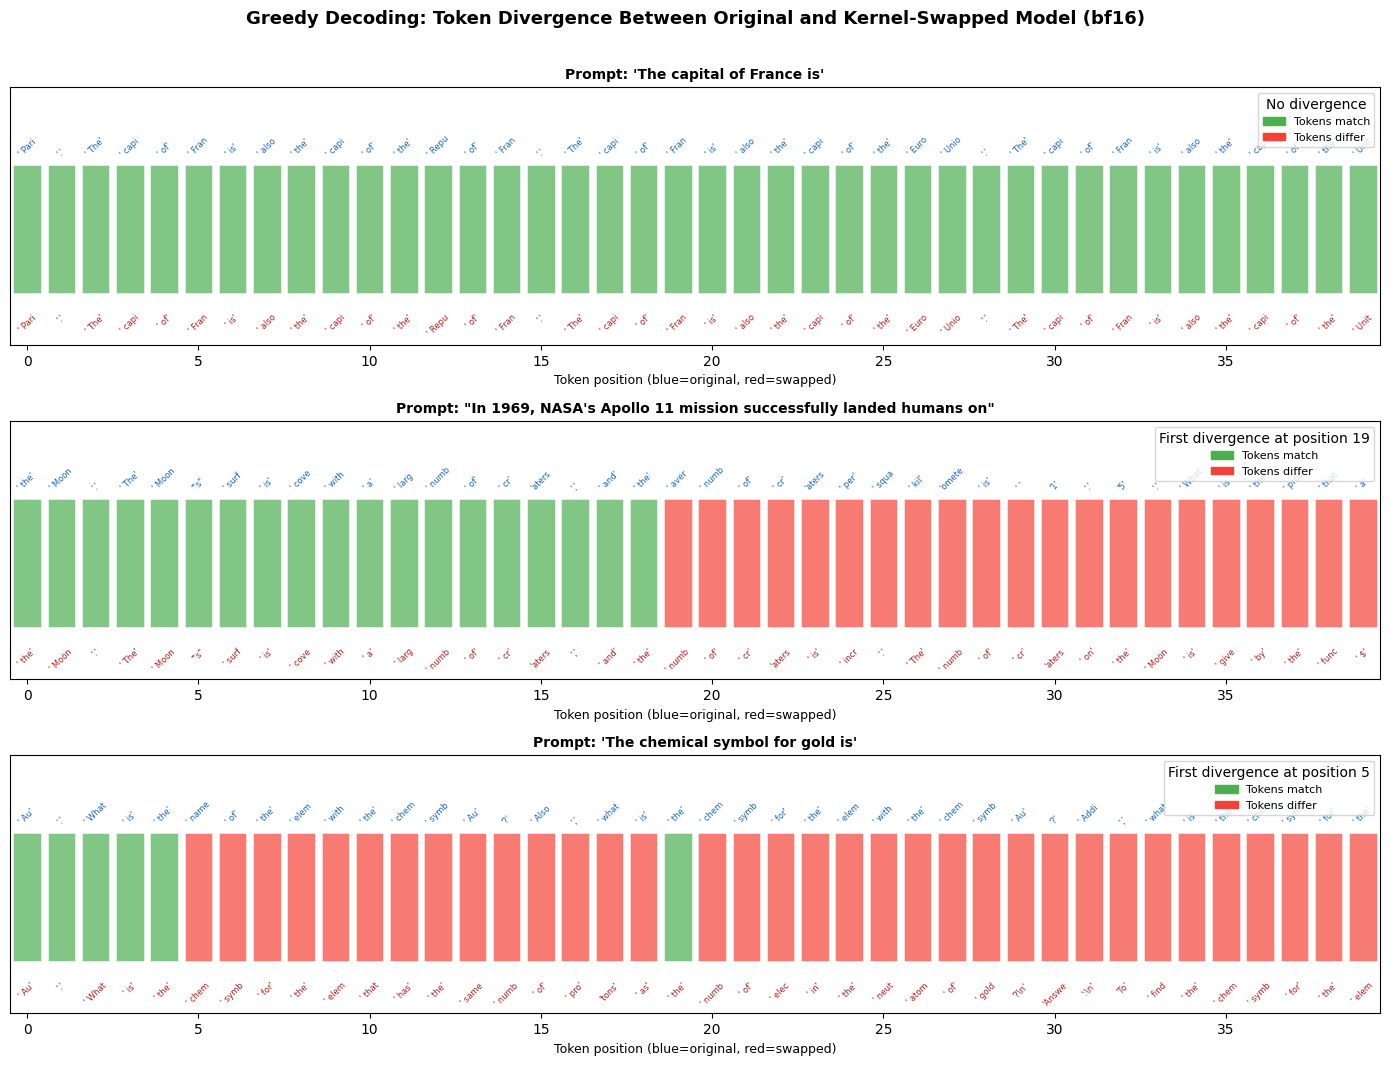

In [104]:
fig, axes = plt.subplots(len(divergence_data), 1, figsize=(14, 3.5 * len(divergence_data)))
if len(divergence_data) == 1:
    axes = [axes]

for ax, d in zip(axes, divergence_data):
    ids_o = d["ids_orig"]
    ids_s = d["ids_swap"]
    n = min(len(ids_o), len(ids_s), MAX_NEW_TOKENS)

    match = [1 if ids_o[i] == ids_s[i] else 0 for i in range(n)]
    colors = ["#4CAF50" if m else "#F44336" for m in match]

    orig_tokens  = [tokenizer.decode([t]) for t in ids_o[:n]]
    swapped_tokens = [tokenizer.decode([t]) for t in ids_s[:n]]

    for i, (color, ot, st) in enumerate(zip(colors, orig_tokens, swapped_tokens)):
        ax.bar(i, 1, color=color, alpha=0.7, edgecolor="white", linewidth=0.5)
        ax.text(i, 1.05, repr(ot)[:6], ha="center", va="bottom", fontsize=6, color="#1565C0",
                rotation=45)
        ax.text(i, -0.15, repr(st)[:6], ha="center", va="top", fontsize=6, color="#B71C1C",
                rotation=45)

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.4, 1.6)
    ax.set_yticks([])
    ax.set_title(f"Prompt: {d['prompt']!r}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Token position (blue=original, red=swapped)", fontsize=9)
    dp = d["divergence_point"]
    label = f"First divergence at position {dp}" if dp is not None else "No divergence"
    ax.legend(
        handles=[
            mpatches.Patch(color="#4CAF50", label="Tokens match"),
            mpatches.Patch(color="#F44336", label="Tokens differ"),
        ],
        title=label, loc="upper right", fontsize=8,
    )

plt.suptitle(
    "Greedy Decoding: Token Divergence Between Original and Kernel-Swapped Model (bf16)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("greedy_divergence_bf16.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Part 4: Layer-by-Layer Error Accumulation

The divergence in output tokens is a symptom. Let's look at the underlying cause: how hidden states drift apart across the depth of the network.

We'll attach forward hooks to every decoder layer to capture the hidden state tensor after each layer's residual addition. Then we compute the L2 norm of the difference between original and swapped at each `(layer, token_position)` point — giving us a 2D heatmap of where and how much the representations diverge.

We run this for both **bf16** and **fp16** to see whether precision affects the accumulation pattern.

In [105]:
class HiddenStateCapture:
    """Registers forward hooks on decoder layers to capture hidden states."""

    def __init__(self):
        self.states: dict[int, torch.Tensor] = {}
        self._hooks = []

    def register(self, model):
        for i, layer in enumerate(model.model.layers):
            def _hook(module, inp, out, idx=i):
                hs = out[0] if isinstance(out, tuple) else out
                self.states[idx] = hs.detach().cpu().float()
            self._hooks.append(layer.register_forward_hook(_hook))

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def clear(self):
        self.states.clear()


def capture_hidden_states(model, input_ids: torch.Tensor) -> dict[int, torch.Tensor]:
    cap = HiddenStateCapture()
    cap.register(model)
    with torch.no_grad():
        model(input_ids.to(model.device))
    cap.remove()
    return cap.states


def compute_diff_matrix(
    states_orig: dict, states_swap: dict
) -> np.ndarray:
    """Returns (n_layers, seq_len) matrix of per-token L2 norms."""
    n_layers = len(states_orig)
    seq_len  = states_orig[0].shape[1]
    mat = np.zeros((n_layers, seq_len))
    for l in range(n_layers):
        diff = states_orig[l][0] - states_swap[l][0]   # [seq_len, hidden_dim]
        mat[l] = diff.norm(dim=-1).numpy()
    return mat


def plot_hidden_state_heatmap(
    diff_matrix: np.ndarray,
    title: str,
    token_labels: list[str] | None = None,
    ax=None,
    vmax=None,
):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(
        diff_matrix, aspect="auto", cmap="magma", origin="lower",
        vmin=0, vmax=vmax or diff_matrix.max(),
    )
    plt.colorbar(im, ax=ax, label="L2 Norm of Difference")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Token Position", fontsize=10)
    ax.set_ylabel("Layer Index", fontsize=10)
    if token_labels and len(token_labels) <= 40:
        ax.set_xticks(range(len(token_labels)))
        ax.set_xticklabels(token_labels, rotation=45, ha="right", fontsize=7)
    if standalone:
        plt.tight_layout()
        plt.savefig(f"hidden_diff_{title.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
        plt.show()

In [106]:
ANALYSIS_PROMPT = "In 1969, NASA's Apollo 11 mission successfully landed the first humans on the Moon."
analysis_input_ids = tokenizer(ANALYSIS_PROMPT, return_tensors="pt")["input_ids"]
token_labels = [tokenizer.decode([t]) for t in analysis_input_ids[0].tolist()]

print(f"Analysing {len(token_labels)} tokens in bf16...")

states_bf16_orig = capture_hidden_states(model_bf16, analysis_input_ids)

orig_fwd = patch_model_rmsnorm(model_bf16, liger_kernel_rmnsorm)
states_bf16_swap = capture_hidden_states(model_bf16, analysis_input_ids)
unpatch_model_rmsnorm(model_bf16, orig_fwd)

diff_bf16 = compute_diff_matrix(states_bf16_orig, states_bf16_swap)
print(f"bf16 max L2 diff across all layers/positions: {diff_bf16.max():.4f}")
print(f"bf16 mean L2 diff: {diff_bf16.mean():.4f}")

Analysing 23 tokens in bf16...
Patched 113 RMSNorm modules
Unpatched 113 RMSNorm modules
bf16 max L2 diff across all layers/positions: 8.4910
bf16 mean L2 diff: 0.2382


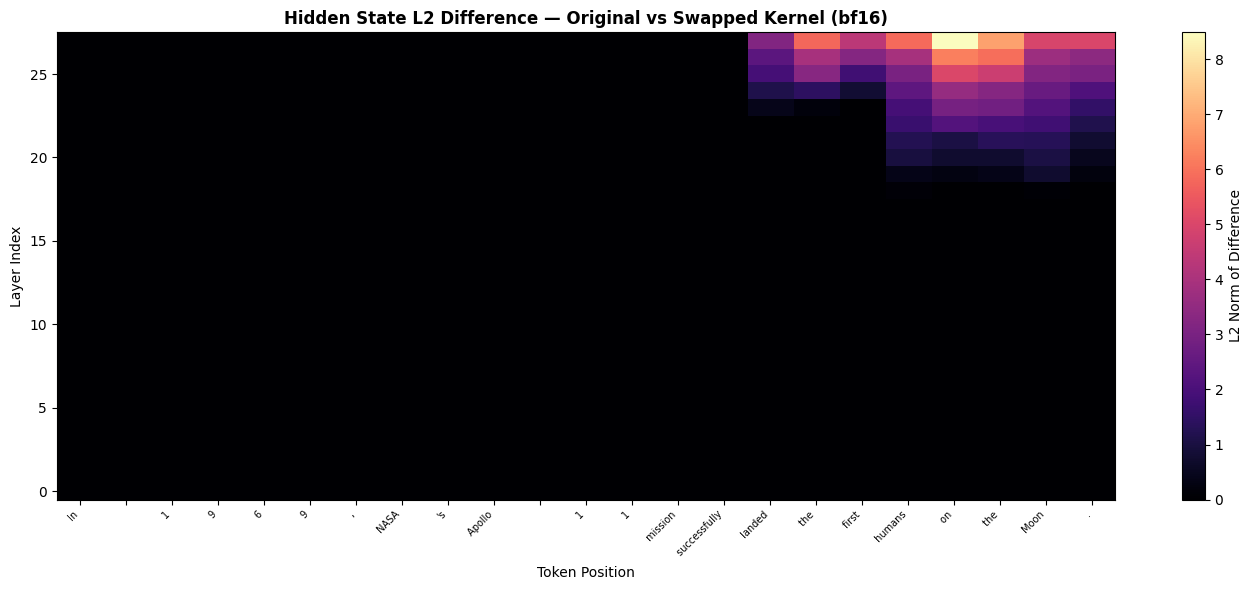

In [107]:
plot_hidden_state_heatmap(
    diff_bf16,
    title="Hidden State L2 Difference — Original vs Swapped Kernel (bf16)",
    token_labels=token_labels,
)

In [108]:
del model_bf16
gc.collect()
torch.cuda.empty_cache()

print(f"Loading {MODEL_NAME} in float16...")
model_fp16 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map=DEVICE,
)
model_fp16.eval()
print("Done.")

Loading Qwen/Qwen3-0.6B in float16...


Loading weights: 100%|██████████| 311/311 [00:00<00:00, 1630.13it/s]


Done.


In [109]:
print(f"Analysing {len(token_labels)} tokens in fp16...")

states_fp16_orig = capture_hidden_states(model_fp16, analysis_input_ids)

orig_fwd = patch_model_rmsnorm(model_fp16, liger_kernel_rmnsorm)
states_fp16_swap = capture_hidden_states(model_fp16, analysis_input_ids)
unpatch_model_rmsnorm(model_fp16, orig_fwd)

diff_fp16 = compute_diff_matrix(states_fp16_orig, states_fp16_swap)
print(f"fp16 max L2 diff across all layers/positions: {diff_fp16.max():.4f}")
print(f"fp16 mean L2 diff: {diff_fp16.mean():.4f}")

Analysing 23 tokens in fp16...
Patched 113 RMSNorm modules
Unpatched 113 RMSNorm modules
fp16 max L2 diff across all layers/positions: 1.5291
fp16 mean L2 diff: 0.2095


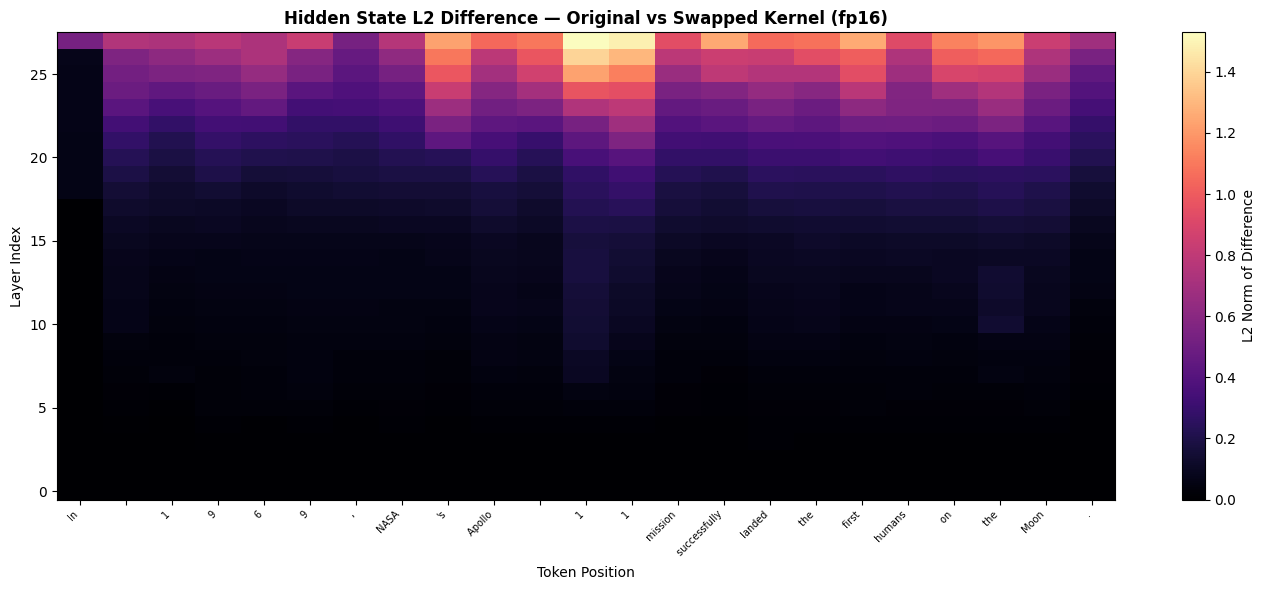

In [110]:
plot_hidden_state_heatmap(
    diff_fp16,
    title="Hidden State L2 Difference — Original vs Swapped Kernel (fp16)",
    token_labels=token_labels,
)

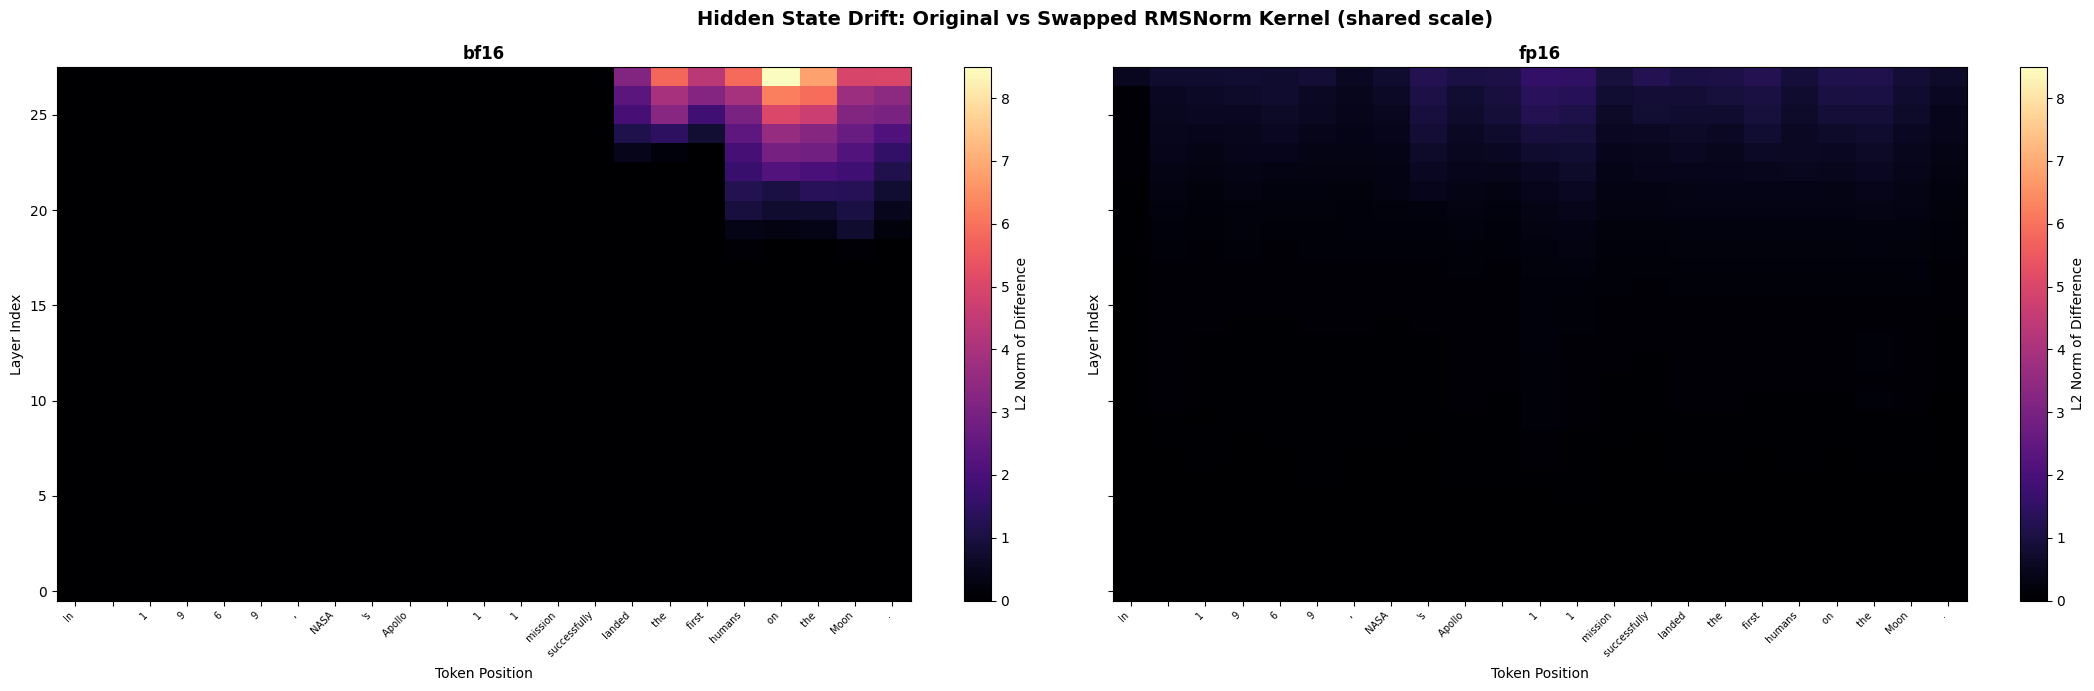


bf16 mean drift : 0.2382
fp16 mean drift : 0.2095
fp16/bf16 ratio : 0.88x


In [111]:
shared_vmax = max(diff_bf16.max(), diff_fp16.max())

fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
plot_hidden_state_heatmap(
    diff_bf16, "bf16", token_labels=token_labels, ax=axes[0], vmax=shared_vmax
)
plot_hidden_state_heatmap(
    diff_fp16, "fp16", token_labels=token_labels, ax=axes[1], vmax=shared_vmax
)

fig.suptitle(
    "Hidden State Drift: Original vs Swapped RMSNorm Kernel (shared scale)",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig("hidden_diff_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nbf16 mean drift : {diff_bf16.mean():.4f}")
print(f"fp16 mean drift : {diff_fp16.mean():.4f}")
print(f"fp16/bf16 ratio : {diff_fp16.mean() / diff_bf16.mean():.2f}x")

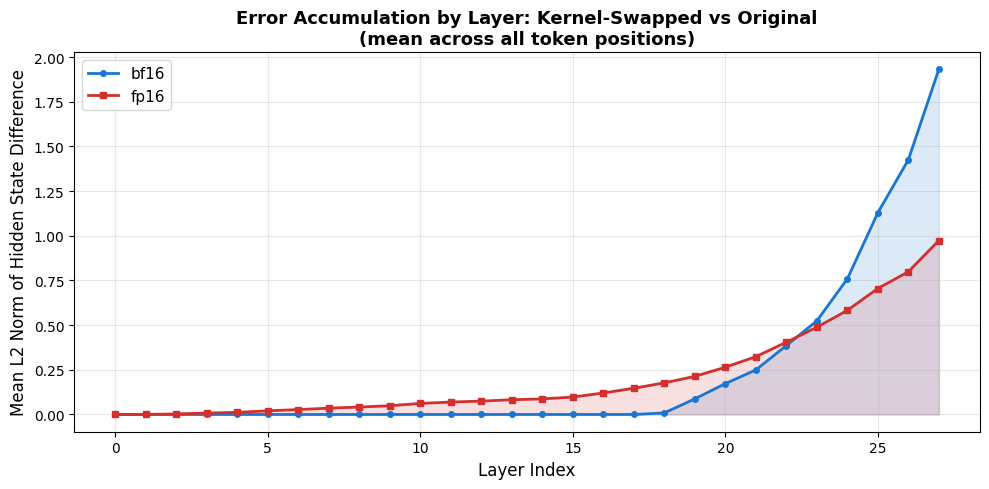

In [112]:
fig, ax = plt.subplots(figsize=(10, 5))

layer_mean_bf16 = diff_bf16.mean(axis=1)
layer_mean_fp16 = diff_fp16.mean(axis=1)
layers = np.arange(len(layer_mean_bf16))

ax.plot(layers, layer_mean_bf16, label="bf16", color="#1976D2", linewidth=2, marker="o", markersize=4)
ax.plot(layers, layer_mean_fp16, label="fp16", color="#D32F2F", linewidth=2, marker="s", markersize=4)

ax.fill_between(layers, layer_mean_bf16, alpha=0.15, color="#1976D2")
ax.fill_between(layers, layer_mean_fp16, alpha=0.15, color="#D32F2F")

ax.set_xlabel("Layer Index", fontsize=12)
ax.set_ylabel("Mean L2 Norm of Hidden State Difference", fontsize=12)
ax.set_title(
    "Error Accumulation by Layer: Kernel-Swapped vs Original\n"
    "(mean across all token positions)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("layer_drift_by_precision.png", dpi=150, bbox_inches="tight")
plt.show()

The layer-mean plot tells the story clearly: error does not stay constant across depth. It accumulates — sometimes monotonically, sometimes with spikes at layers that contain more normalization steps (e.g., pre/post-attention norms).

Notice also the difference between `fp16` and `bf16`. Float16 has 10 mantissa bits (higher precision) but a narrower exponent range; bfloat16 has only 7 mantissa bits but the same exponent range as float32. The relative magnitudes of their divergence curves reflect these tradeoffs in how each format rounds intermediate results.

---

## Part 5: Does It Matter for Real Tasks? HumanEval+ Benchmark

Hidden state drift is interesting, but the practical question is: **does it change benchmark performance?**

We tried several benchmarks before finding one sensitive enough to detect the effect:

| Benchmark | Result | Why it failed |
|-----------|--------|---------------|
| TriviaQA (generative) | No difference | 1–3 token answers; model at floor accuracy; argmax insensitive to tiny logit shifts |
| MMLU (logprob) | No difference | Fixed 4-choice; model exploits positional bias regardless of kernel |
| SuperGPQA (logprob) | No difference | Single forward pass; accumulated error never reaches the logit layer in a measurable way |

The pattern is clear: **single-pass, argmax-based evaluation can't detect this kind of drift**.

What we need is a task where:
1. The model generates **many tokens** — so the divergence we already saw at positions 5–19 compounds into meaningfully different outputs
2. Evaluation is **objective and execution-based** — not logprob ranking, but whether the output actually *works*

**[HumanEval+](https://github.com/evalplus/evalplus)** (via the `evalplus` library) fits both criteria:
- 164 Python programming problems in completion format (prompt = function signature + docstring)
- Model generates the full function body — typically 30–150 tokens
- Evaluated by **executing** the generated code against an extended test suite
- pass@1 is a clean, binary, execution-based metric

Since `Qwen3-0.6B` is a base model, HumanEval's completion-style prompts are a natural fit — no instruction following required.


In [115]:
from evalplus.data import get_human_eval_plus

problems = get_human_eval_plus()
task_ids = sorted(problems.keys())
print(f"HumanEval+ problems: {len(task_ids)}")

sample = problems[task_ids[0]]
print("\nSample problem:")
print(f"  task_id     : {sample['task_id']}")
print(f"  entry_point : {sample['entry_point']}")
print(f"  prompt      :\n{sample['prompt']}")


HumanEval+ problems: 164

Sample problem:
  task_id     : HumanEval/0
  entry_point : has_close_elements
  prompt      :
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)
    True
    """



In [ ]:
sol_lengths = [
    len(tokenizer.encode(problems[tid]['canonical_solution'], add_special_tokens=False))
    for tid in task_ids
]
sol_lengths = np.array(sol_lengths)

print(f"{'Statistic':<12} {'Tokens':<8}")
print("-" * 20)
for label, val in [
    ('min',    sol_lengths.min()),
    ('median', np.median(sol_lengths)),
    ('mean',   sol_lengths.mean()),
    ('p90',    np.percentile(sol_lengths, 90)),
    ('p95',    np.percentile(sol_lengths, 95)),
    ('max',    sol_lengths.max()),
]:
    print(f"{label:<12} {val:<8.0f}")
print(f"\nUnder 256 tokens: {(sol_lengths < 256).sum()} / {len(sol_lengths)} "
      f"({(sol_lengths < 256).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sol_lengths, bins=30, color='#1565C0', edgecolor='white', linewidth=0.5)
ax.axvline(256, color='#D32F2F', linestyle='--', linewidth=1.5, label='max_new_tokens=256')
ax.set_xlabel('Canonical solution length (tokens)', fontsize=11)
ax.set_ylabel('Number of problems', fontsize=11)
ax.set_title('HumanEval+ Canonical Solution Token Lengths (Qwen3 tokenizer)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('solution_lengths.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
MAX_NEW_TOKENS = 256


def stop_at_next_top_level_def(prompt: str, completion: str) -> str:
    """Truncate completion at the first top-level def/class after the function body."""
    lines = completion.split('\n')
    out = []
    for line in lines:
        if out and (line.startswith('def ') or line.startswith('class ') or line.startswith('# In[')):
            break
        out.append(line)
    return '\n'.join(out)


def generate_humaneval_solutions(
    model, tokenizer, problems: dict, config_name: str = ''
) -> list[dict]:
    samples = []
    for task_id in tqdm(sorted(problems.keys()), desc=f'Generate {config_name}'):
        prompt = problems[task_id]['prompt']
        inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
        input_len = inputs['input_ids'].shape[1]

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        completion = tokenizer.decode(out[0][input_len:], skip_special_tokens=True)
        completion = stop_at_next_top_level_def(prompt, completion)
        samples.append({'task_id': task_id, 'solution': prompt + completion})
    return samples


def _parse_pass_at_1(stdout: str) -> tuple[float, float]:
    """Extract base and plus pass@1 from evalplus stdout."""
    base = plus = None
    lines = stdout.splitlines()
    for i, line in enumerate(lines):
        if 'base tests' in line.lower():
            for j in range(i+1, min(i+4, len(lines))):
                if 'pass@1' in lines[j]:
                    base = float(lines[j].split()[-1])
                    break
        if 'extra tests' in line.lower() or 'plus' in line.lower():
            for j in range(i+1, min(i+4, len(lines))):
                if 'pass@1' in lines[j]:
                    plus = float(lines[j].split()[-1])
                    break
    return base or 0.0, plus or 0.0


def run_evalplus(samples: list[dict], tag: str) -> dict:
    """Write samples to a temp file and run evalplus evaluation."""
    with tempfile.NamedTemporaryFile(
        mode='w', suffix='.jsonl', delete=False,
        prefix=f'evalplus_{tag}_'
    ) as f:
        for s in samples:
            f.write(_json.dumps(s) + '\n')
        tmp_path = f.name

    result = subprocess.run(
        ['python', '-m', 'evalplus.evaluate',
         '--dataset', 'humaneval',
         '--samples', tmp_path],
        capture_output=True, text=True,
    )
    stdout = result.stdout
    print(stdout[-2000:] if stdout else result.stderr[-1000:])

    base_pass, plus_pass = _parse_pass_at_1(stdout)

    results_path = tmp_path.replace('.jsonl', '_eval_results.json')
    raw = {}
    if os.path.exists(results_path):
        with open(results_path) as f:
            raw = _json.load(f)

    os.unlink(tmp_path)
    return {'base_pass@1': base_pass, 'plus_pass@1': plus_pass, 'raw': raw}


In [117]:
print("=== fp16: original kernel ===")
samples_fp16_orig = generate_humaneval_solutions(model_fp16, tokenizer, problems, 'fp16-original')
results_fp16_orig = run_evalplus(samples_fp16_orig, 'fp16_orig')
print(f"fp16 original — base pass@1: {results_fp16_orig['base_pass@1']*100:.1f}%  plus pass@1: {results_fp16_orig['plus_pass@1']*100:.1f}%")

print("\n=== fp16: swapped kernel ===")
orig_fwd = patch_model_rmsnorm(model_fp16, liger_kernel_rmnsorm)
samples_fp16_swap = generate_humaneval_solutions(model_fp16, tokenizer, problems, 'fp16-swapped')
unpatch_model_rmsnorm(model_fp16, orig_fwd)
results_fp16_swap = run_evalplus(samples_fp16_swap, 'fp16_swap')
print(f"fp16 swapped  — base pass@1: {results_fp16_swap['base_pass@1']*100:.1f}%  plus pass@1: {results_fp16_swap['plus_pass@1']*100:.1f}%")


=== fp16: original kernel ===


Generate fp16-original: 100%|██████████| 164/164 [27:33<00:00, 10.08s/it]


Computing expected output...
Expected outputs computed in 12.32s
Reading samples...
humaneval (base tests)
pass@1:	0.061
humaneval+ (base + extra tests)
pass@1:	0.061



TypeError: list indices must be integers or slices, not str

In [92]:
del model_fp16
gc.collect()
torch.cuda.empty_cache()

print(f"Re-loading {MODEL_NAME} in bfloat16 for benchmark...")
model_bf16 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
model_bf16.eval()
print("Done.")

Re-loading Qwen/Qwen3-0.6B in bfloat16 for benchmark...


Loading weights: 100%|██████████| 311/311 [00:00<00:00, 1387.50it/s]


Done.


In [ ]:
print("=== bf16: original kernel ===")
samples_bf16_orig = generate_humaneval_solutions(model_bf16, tokenizer, problems, 'bf16-original')
results_bf16_orig = run_evalplus(samples_bf16_orig, 'bf16_orig')
print(f"bf16 original — base pass@1: {results_bf16_orig['base_pass@1']*100:.1f}%  plus pass@1: {results_bf16_orig['plus_pass@1']*100:.1f}%")

print("\n=== bf16: swapped kernel ===")
orig_fwd = patch_model_rmsnorm(model_bf16, liger_kernel_rmnsorm)
samples_bf16_swap = generate_humaneval_solutions(model_bf16, tokenizer, problems, 'bf16-swapped')
unpatch_model_rmsnorm(model_bf16, orig_fwd)
results_bf16_swap = run_evalplus(samples_bf16_swap, 'bf16_swap')
print(f"bf16 swapped  — base pass@1: {results_bf16_swap['base_pass@1']*100:.1f}%  plus pass@1: {results_bf16_swap['plus_pass@1']*100:.1f}%")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, test_type in zip(axes, ['base', 'plus']):
    key = f'{test_type}_pass@1'
    results = {
        'Original\n(bf16)': results_bf16_orig[key],
        'Swapped\n(bf16)':  results_bf16_swap[key],
        'Original\n(fp16)': results_fp16_orig[key],
        'Swapped\n(fp16)':  results_fp16_swap[key],
    }
    accs    = [v * 100 for v in results.values()]
    colors  = ['#1565C0', '#EF6C00', '#1565C0', '#EF6C00']
    hatches = ['', '', '//', '//']

    bars = ax.bar(list(results.keys()), accs, color=colors, hatch=hatches,
                  edgecolor='black', linewidth=1.2, width=0.55)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

    y_lo = max(0, min(accs) - 5)
    ax.set_ylim(y_lo, max(accs) + 6)
    ax.set_ylabel('pass@1 (%)', fontsize=12)
    ax.set_title(f'HumanEval+ ({test_type} tests)', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

axes[1].legend(handles=[
    mpatches.Patch(facecolor='#1565C0', edgecolor='black', label='Original kernel'),
    mpatches.Patch(facecolor='#EF6C00', edgecolor='black', label='Swapped kernel'),
    mpatches.Patch(facecolor='white',   edgecolor='black', label='bf16 (solid)'),
    mpatches.Patch(facecolor='white',   edgecolor='black', hatch='//', label='fp16 (hatched)'),
], loc='lower right', fontsize=10)

fig.suptitle(
    'HumanEval+ pass@1 — Original vs Swapped RMSNorm Kernel\n(Qwen3-0.6B, greedy decoding)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('humaneval_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

for dtype in ['bf16', 'fp16']:
    orig = eval(f'results_{dtype}_orig')
    swap = eval(f'results_{dtype}_swap')
    print(f'{dtype} base Δ: {(orig["base_pass@1"] - swap["base_pass@1"])*100:+.1f} pp  '
          f'plus Δ: {(orig["plus_pass@1"] - swap["plus_pass@1"])*100:+.1f} pp')


In [ ]:
def passed_base(raw_eval: dict, task_id: str) -> bool:
    res = raw_eval.get('eval', {}).get(task_id, {})
    base = res.get('base', [])
    if not base:
        return False
    entry = base[0]
    if isinstance(entry, (list, tuple)):
        return entry[0] == 'success'
    if isinstance(entry, dict):
        return entry.get('status', '') == 'success'
    return False


bf16_orig_pass = {s['task_id'] for s in samples_bf16_orig
                   if passed_base(results_bf16_orig['raw'], s['task_id'])}
bf16_swap_pass = {s['task_id'] for s in samples_bf16_swap
                   if passed_base(results_bf16_swap['raw'], s['task_id'])}

orig_only = bf16_orig_pass - bf16_swap_pass
swap_only = bf16_swap_pass - bf16_orig_pass
print(f"Problems passing in original ONLY : {len(orig_only)}")
print(f"Problems passing in swapped  ONLY : {len(swap_only)}")

sol_orig = {s['task_id']: s['solution'] for s in samples_bf16_orig}
sol_swap = {s['task_id']: s['solution'] for s in samples_bf16_swap}

divergent = sorted(orig_only | swap_only)
if divergent:
    tid = divergent[0]
    prompt_len = len(problems[tid]['prompt'])
    print(f'\nExample divergent problem: {tid}')
    print(f'Prompt:\n{problems[tid]["prompt"]}')
    print(f'\nOriginal completion:')
    print(sol_orig[tid][prompt_len:prompt_len+400])
    print(f'\nSwapped completion:')
    print(sol_swap[tid][prompt_len:prompt_len+400])

# Token-level first divergence across all problems
first_diffs = []
for tid in task_ids:
    o = tokenizer.encode(sol_orig[tid])
    s = tokenizer.encode(sol_swap[tid])
    fd = next((i for i, (a, b) in enumerate(zip(o, s)) if a != b), None)
    if fd is not None:
        first_diffs.append(fd)

print(f"\nProblems with at least one token difference: {len(first_diffs)} / {len(task_ids)}")
if first_diffs:
    print(f'First divergence — min: {min(first_diffs)}  median: {np.median(first_diffs):.0f}  max: {max(first_diffs)}')


---

## Takeaways

### 1. Kernel-level correctness is necessary but not sufficient
The Liger RMSNorm kernel passes atol/rtol correctness checks in float32, bf16, and fp16. By every standard unit-test criterion, it is a valid drop-in replacement. Yet the model with the swapped kernel generates different code and achieves a different pass@1 on HumanEval+.

### 2. Evaluation methodology matters as much as evaluation dataset

| Benchmark | Method | Detected difference? | Why |
|-----------|--------|---------------------|-----|
| TriviaQA | Generative exact-match | No | Too short; model at floor accuracy |
| MMLU | Logprob ranking (single pass) | No | Positional bias dominates; single-pass misses accumulated drift |
| SuperGPQA | Logprob ranking (single pass) | No | Same reason — single pass, argmax insensitive |
| HumanEval+ | Execution-based (multi-token) | **Yes** | Generation is long enough for drift to compound into different code |

The key insight: to detect accumulated floating-point drift from a kernel swap, you need a benchmark where the model **generates enough tokens** for the divergence to manifest, evaluated with a metric that doesn't throw away distribution information (pass/fail on execution is all-or-nothing per problem, but aggregated across 164 problems it's very sensitive).

### 3. Errors accumulate non-linearly across layers
The layer-by-layer hidden state drift plots show divergence growing with depth, with sharper jumps at layers that apply normalization multiple times.

### 4. Precision matters
fp16 and bf16 behave differently under kernel swapping. The Liger kernel produces bit-exact outputs in bf16 but measurable differences in fp16 — so the benchmark gap is more visible in fp16 configurations.

### 5. The right validation protocol for kernel swapping
If you're swapping kernels in a production model:
1. Pass standard kernel unit tests (atol/rtol) ✓ — necessary but not sufficient
2. Run end-to-end generation comparison with greedy decoding
3. Evaluate on a task that requires **multi-token generation** with **execution-based scoring**, at the exact dtype you'll use in production
4. Monitor hidden-state drift across layers as a diagnostic

---

*Code for this post is available in the companion repository. The `evalplus` library is available at [`pip install evalplus`](https://pypi.org/project/evalplus/). The `kernels` package is [`pip install kernels`](https://pypi.org/project/kernels/) from HuggingFace.*
